In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
poke = pd.read_csv('../Week2/Dataset/Pokemon.csv')
print(poke.head(10))
print(poke.info())# Display a summary of the dataset, including column names, data types, and missing values.
print(poke.shape)# Displays the rows, columns and data types

   ID        Name Form  Type1   Type2  Total  HP  Attack  Defense  Sp. Atk  \
0   1   Bulbasaur       Grass  Poison    318  45      49       49       65   
1   2     Ivysaur       Grass  Poison    405  60      62       63       80   
2   3    Venusaur       Grass  Poison    525  80      82       83      100   
3   4  Charmander        Fire            309  39      52       43       60   
4   5  Charmeleon        Fire            405  58      64       58       80   
5   6   Charizard        Fire  Flying    534  78      84       78      109   
6   7    Squirtle       Water            314  44      48       65       50   
7   8   Wartortle       Water            405  59      63       80       65   
8   9   Blastoise       Water            530  79      83      100       85   
9  10    Caterpie         Bug            195  45      30       35       20   

   Sp. Def  Speed  Generation  
0       65     45           1  
1       80     60           1  
2      100     80           1  
3       50   

In [8]:
#seperating numerical columns and non numeric columns
numeric_cols = poke.select_dtypes(include=np.number).columns.tolist()
non_numeric_cols = poke.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric Columns: ",numeric_cols)
print("Non Numeric Columns: ",non_numeric_cols)

Numeric Columns:  ['ID', 'Total', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Generation']
Non Numeric Columns:  ['Name', 'Form', 'Type1', 'Type2']


In [9]:
# Quick summary of all numeric columns
poke.describe()

,ID,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
count,1215.000000,1215.000000,1215.000000,1215.000000,1215.000000,1215.000000,1215.000000,1215.000000,1215.000000
mean,501.735802,443.104527,71.244444,81.152263,75.007407,73.224691,72.441152,70.034568,5.059259
std,298.979081,121.193406,26.927819,32.037134,30.740999,32.757152,27.578188,30.161298,2.595100
min,1.000000,175.000000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.000000
25%,240.500000,332.000000,52.000000,57.000000,52.000000,50.000000,51.000000,45.000000,3.000000
50%,495.000000,465.000000,70.000000,80.000000,70.000000,65.000000,70.000000,68.000000,5.000000
75%,753.500000,521.000000,85.000000,100.000000,91.000000,95.000000,90.000000,91.000000,7.000000
max,1025.000000,1125.000000,255.000000,190.000000,250.000000,194.000000,250.000000,200.000000,9.000000


`describe()` gives count, mean, std, min, max, and quartiles for numeric columns in one shot.
Below that, I compute mean/median/mode/variance/std manually for a couple of key columns
just to make sure I understand what each one means.

In [22]:
#taking of the numeric columns
key_cols = numeric_cols[1]
print("Current Column: ", key_cols)

means = poke[key_cols].mean()
medians = poke[key_cols].median()
modes = poke[key_cols].mode()[0]   # mode() can return more than one value, so take the first
variances = poke[key_cols].var()
stds = poke[key_cols].std()

print(f"Mean:     {means:.2f}")
print(f"Median:   {medians:.2f}")
print(f"Mode:     {modes:.2f}")
print(f"Variance: {variances:.2f}")
print(f"Std Dev:  {stds:.2f}")


Current Column:  Total
Mean:     443.10
Median:   465.00
Mode:     600.00
Variance: 14687.84
Std Dev:  121.19


Correlation tells us how strongly two numeric columns move together.
+1 = strong positive relationship, -1 = strong negative relationship, 0 = no relationship.

In [ ]:
# If both columns increase or decrease together, the correlation is positive.
# If one increases while the other decreases, the correlation is negative.
# If Changes in one column do not show any consistent relationship with the other column, it is no correlation  
corr = poke[numeric_cols].corr()
corr

,ID,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
ID,1.000000,0.154949,0.162895,0.126007,0.096745,0.092593,0.084208,0.067173,0.836086
Total,0.154949,1.000000,0.659951,0.730260,0.639458,0.718040,0.721204,0.562274,0.184667
HP,0.162895,0.659951,1.000000,0.461580,0.332312,0.357712,0.393706,0.181531,0.139122
Attack,0.126007,0.730260,0.461580,1.000000,0.468231,0.327944,0.274610,0.375532,0.177983
Defense,0.096745,0.639458,0.332312,0.468231,1.000000,0.231159,0.532877,0.017904,0.118469
Sp. Atk,0.092593,0.718040,0.357712,0.327944,0.231159,1.000000,0.514482,0.425423,0.099514
Sp. Def,0.084208,0.721204,0.393706,0.274610,0.532877,0.514482,1.000000,0.238500,0.090388
Speed,0.067173,0.562274,0.181531,0.375532,0.017904,0.425423,0.238500,1.000000,0.117294
Generation,0.836086,0.184667,0.139122,0.177983,0.118469,0.099514,0.090388,0.117294,1.000000


Histograms figure shows us the distribution by grouping values in ranges called bins and counting how many falls under it

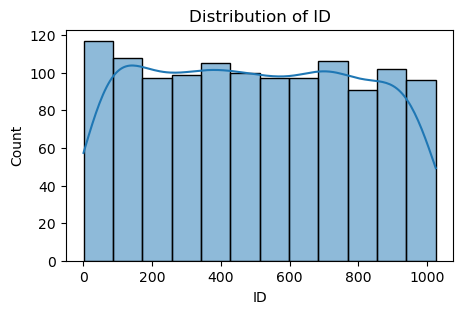

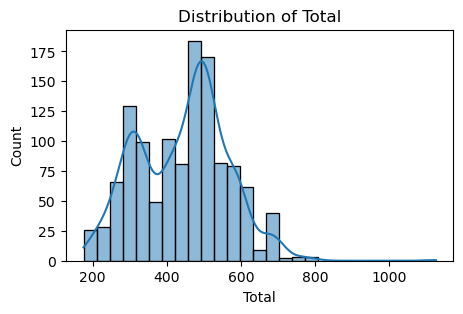

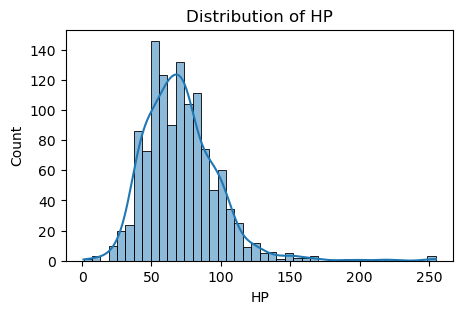

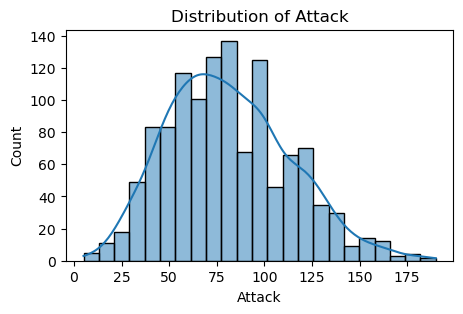

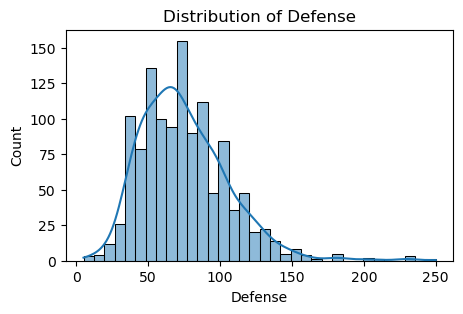

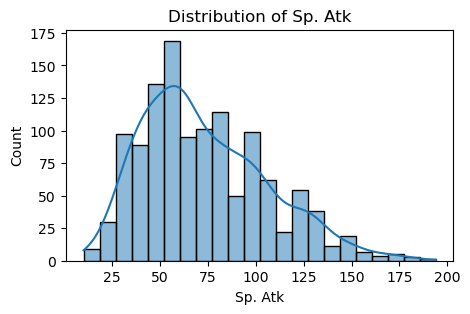

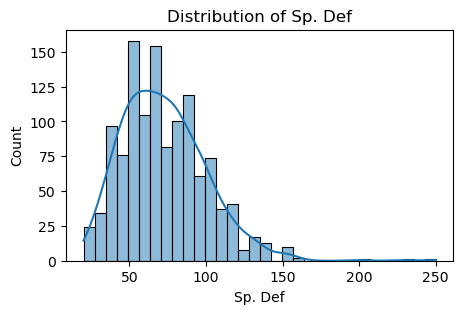

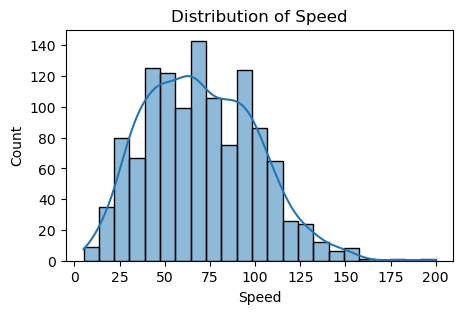

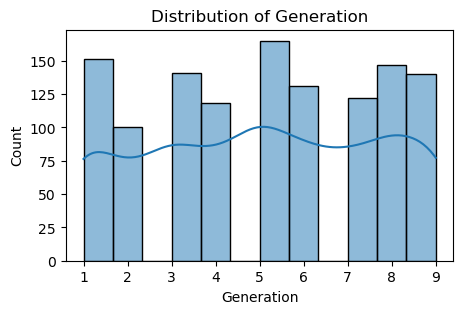

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(5, 3))
    sns.histplot(poke[col], kde=True)  # kde=True adds a smooth curve over the bars
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

Box plots show the median, the middle 50% of the data (the box), and any outliers (dots).

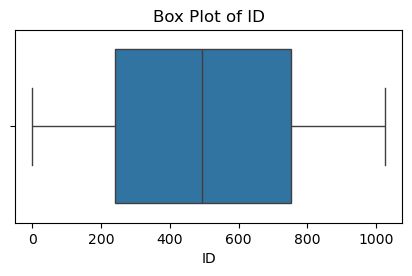

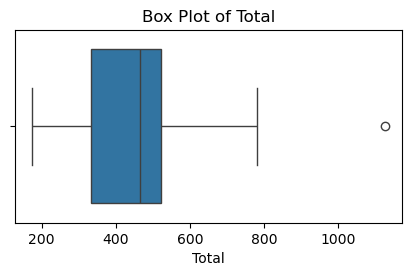

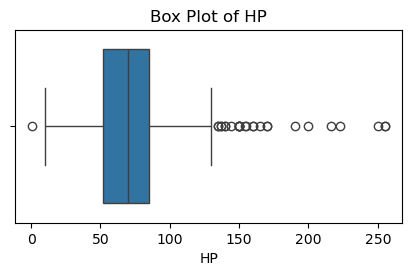

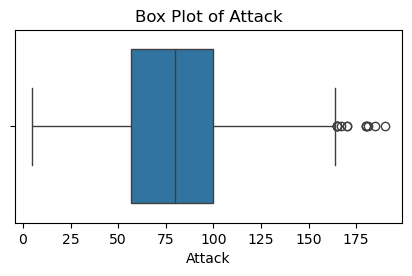

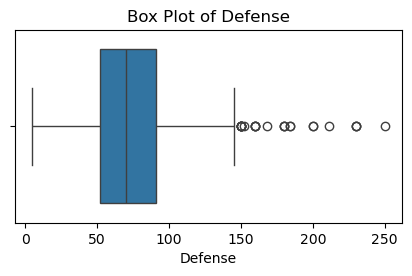

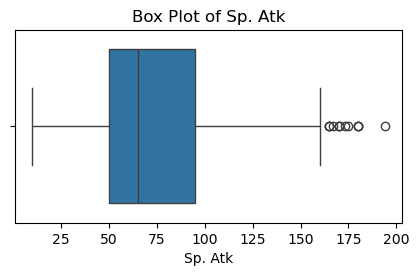

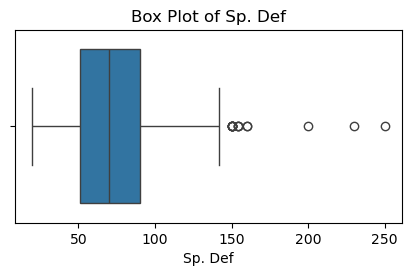

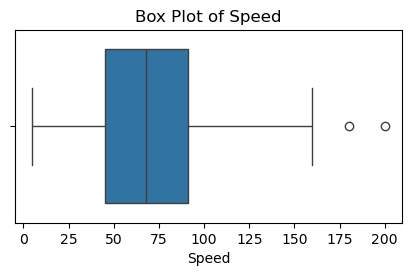

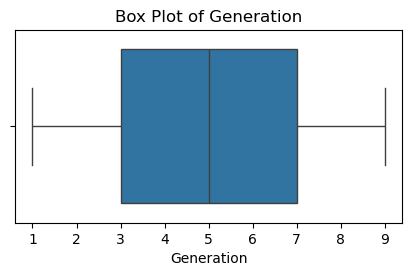

In [15]:
for col in numeric_cols:
    plt.figure(figsize=(5, 2.5))
    sns.boxplot(x=poke[col])
    plt.title(f'Box Plot of {col}')
    plt.show()

Scatter plots help us see if two numeric columns are related to each other.
I'll compare the first two numeric columns as an example

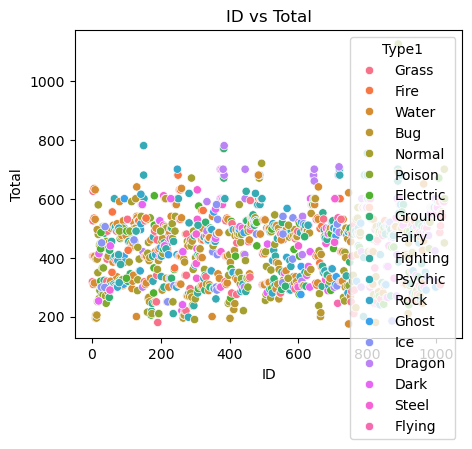

In [24]:
if len(numeric_cols)>=2 and len(non_numeric_cols)>=1:
    hue_col = non_numeric_cols[2]
    x, y = numeric_cols[0], numeric_cols[1]

    plt.figure(figsize=(5,4))
    sns.scatterplot(data = poke, x = x, y = y, hue= hue_col)
    plt.title(f'{x} vs {y}')
    plt.show()
else:
    print("Not enough columns")

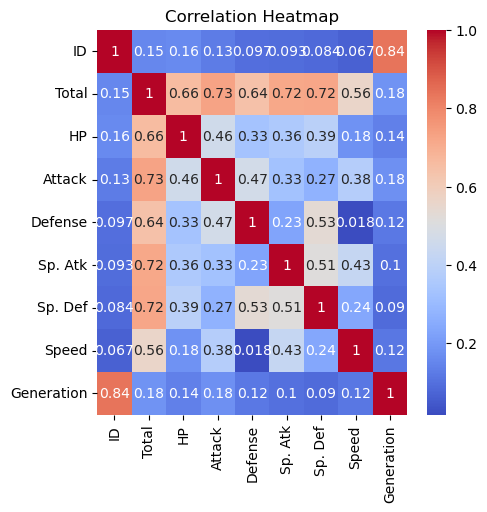

In [20]:
#heatmap

plt.figure(figsize=(5,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

Insights:

Histogram

1. Most base stats (HP, Attack, Defense, Sp. Atk, Sp. Def, Speed) are right-skewed, with a few outliers stretching the tail. Total is the most symmetric, since it averages the rest out.

Boxplot

2. HP and Defense have the most outliers, with some stretching up to around 250, much higher than the typical 50–90 range. Speed and Total, on the other hand, have almost no outliers, meaning even the strongest Pokémon tend to stay close to typical Speed.

Scatter plot

3. Attack and Defense show a moderate positive relationship (Pokémon with high Attack tend to also have decent Defense), but Defense and Speed show almost no relationship at all, meaning bulk and speed are largely independent traits in Pokémon design, unlike Attack and Defense which tend to move together somewhat.

Heatmap

4. The heatmap confirms the scatter plot findings. Attack and Defense have a moderate positive correlation (0.47), while Defense and Speed are essentially uncorrelated (0.02). It also shows Sp. Atk and Sp. Def move together somewhat (0.51), and that HP is only weakly linked to the other stats, suggesting HP is assigned fairly independently of a Pokémon's other combat stats.